# Task 9 – Basic Data Analysis of Sensor Data

Analysis of the sensor data collected with the *Sensor Data Collector App* (Android)
and exported from the data collection service as a single JSON file (`data/data.json`).

The file contains a JSON **array** of records. Each record has the structure:

```json
{
  "id": "<uuid>",
  "patient_id": 0,
  "experiment_id": 3,
  "data": {
    "accuracy": 3,
    "data": [x, y, z],
    "device": "Google Pixel 8 Pro",
    "sensorId": "...",
    "sensorType": 1 | 4 | 10,
    "timestamp": <ns since boot>,
    "friendlyTimeStamp": "..."
  }
}
```

Recorded sensors and their units:

| `sensorType` | Sensor | Unit |
|---|---|---|
| 1 | Accelerometer (incl. gravity) | m/s² |
| 4 | Gyroscope (angular velocity) | rad/s |
| 10 | Linear Acceleration (gravity removed) | m/s² |

## 1. Load the data

In [1]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

with open('data/data.json', 'r') as file:
    records = json.load(file)

print(f'Total records: {len(records)}')

Total records: 513


## 2. Preprocessing

Flatten the nested `data` object into columns, split the measurement array into
separate `x`, `y`, `z` columns, parse the timestamps and sort the readings chronologically.

In [2]:
# Flatten the nested 'data' object (nested fields get a 'data.' prefix)
df = pd.json_normalize(records)
df.columns = [col.replace('data.', '') for col in df.columns]

# Split the measurement array into one column per axis
df[['x', 'y', 'z']] = pd.DataFrame(df['data'].tolist(), index=df.index)
df = df.drop(columns=['data'])

# Parse the wall-clock timestamp and sort chronologically
df['time'] = pd.to_datetime(df['friendlyTimeStamp'])
df = df.sort_values('time').reset_index(drop=True)

# Seconds elapsed since the first reading (sensor timestamp is in ns)
df['t_rel'] = (df['timestamp'] - df['timestamp'].min()) / 1e9

df.head()

,id,patient_id,experiment_id,accuracy,device,experimentId,friendlyTimeStamp,patientId,sensorId,sensorType,timestamp,x,y,z,time,t_rel
0,86f32e0e-6663-11f1-a6b9-6ca100562018,0,0,3,Google Pixel 8 Pro,0,2026-07-02 00:02:22.945,0,ICM45631 Gyroscope,4,3761126248197974,0.108300,-0.005113,0.038587,2026-07-02 00:02:22.945,0.000000
1,86f3a617-6663-11f1-8966-6ca100562018,0,0,3,Google Pixel 8 Pro,0,2026-07-02 00:02:23.006,0,ICM45631 Accelerometer,1,3761126308465878,-1.119439,3.027393,9.390807,2026-07-02 00:02:23.006,0.060268
2,86f37f0d-6663-11f1-bd7a-6ca100562018,0,0,3,Google Pixel 8 Pro,0,2026-07-02 00:02:23.106,0,ICM45631 Gyroscope,4,3761126408875262,0.305549,-0.112147,0.057156,2026-07-02 00:02:23.106,0.160677
3,86f55638-6663-11f1-9873-6ca100562018,0,0,3,Google Pixel 8 Pro,0,2026-07-02 00:02:23.126,0,Linear Acceleration Sensor,10,3761126428956153,-0.318250,1.478847,-1.387280,2026-07-02 00:02:23.126,0.180758
4,86f5081c-6663-11f1-8ef1-6ca100562018,0,0,3,Google Pixel 8 Pro,0,2026-07-02 00:02:23.166,0,ICM45631 Accelerometer,1,3761126469120663,-0.573112,3.503166,9.143307,2026-07-02 00:02:23.166,0.220923


## 3. Overview of the dataset

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 513 entries, 0 to 512
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   id                 513 non-null    object        
 1   patient_id         513 non-null    int64         
 2   experiment_id      513 non-null    int64         
 3   accuracy           513 non-null    int64         
 4   device             513 non-null    object        
 5   experimentId       513 non-null    int64         
 6   friendlyTimeStamp  513 non-null    object        
 7   patientId          513 non-null    int64         
 8   sensorId           513 non-null    object        
 9   sensorType         513 non-null    int64         
 10  timestamp          513 non-null    int64         
 11  x                  513 non-null    float64       
 12  y                  513 non-null    float64       
 13  z                  513 non-null    float64       
 14  time      

In [4]:
duration = df['t_rel'].max()

print('Patients:    ', df['patient_id'].unique())
print('Experiments: ', df['experiment_id'].unique())
print('Devices:     ', df['device'].unique())
print('Accuracy:    ', df['accuracy'].unique())
print('Time range:  ', df['time'].min(), '→', df['time'].max())
print(f'Duration:     {duration:.1f} s')
print()
print('Readings per sensor:')
print(df['sensorId'].value_counts())
print()
print('Approx. sampling rate per sensor [Hz]:')
print((df['sensorId'].value_counts() / duration).round(1))

Patients:     [0]
Experiments:  [0]
Devices:      ['Google Pixel 8 Pro']
Accuracy:     [3]
Time range:   2026-07-02 00:02:22.945000 → 2026-07-02 00:02:51.542000
Duration:     28.6 s

Readings per sensor:
sensorId
ICM45631 Gyroscope            179
ICM45631 Accelerometer        177
Linear Acceleration Sensor    157
Name: count, dtype: int64

Approx. sampling rate per sensor [Hz]:
sensorId
ICM45631 Gyroscope            6.3
ICM45631 Accelerometer        6.2
Linear Acceleration Sensor    5.5
Name: count, dtype: float64


## 4. Summary statistics per sensor

The three sensors measure different physical quantities, so we analyse them separately.

In [5]:
df.groupby('sensorId')[['x', 'y', 'z']].describe().round(3).T

sensorId  ICM45631 Accelerometer  ICM45631 Gyroscope  \
x count                  177.000             179.000   
  mean                     1.937               0.008   
  std                      2.952               0.879   
  min                     -4.766              -2.941   
  25%                      0.358              -0.394   
  50%                      1.264               0.087   
  75%                      2.564               0.618   
  max                     16.070               3.792   
y count                  177.000             179.000   
  mean                    -8.634              -0.306   
  std                      4.232               0.940   
  min                    -29.881              -4.678   
  25%                    -10.436              -0.785   
  50%                     -9.371              -0.286   
  75%                     -7.701               0.143   
  max                      3.558               4.514   
z count                  177.000             179.000   
  mean                    -0.751              -0.017   
  std                      2.816               0.665   
  min                     -6.738              -2.587   
  25%                     -1.537              -0.319   
  50%                     -0.832               0.003   
  75%                     -0.327               0.265   
  max                      9.391               3.735   

sensorId  Linear Acceleration Sensor  
x count                      157.000  
  mean                        -0.229  
  std                          2.529  
  min                         -9.564  
  25%                         -1.348  
  50%                         -0.147  
  75%                          1.306  
  max                          5.654  
y count                      157.000  
  mean                        -0.124  
  std                          3.710  
  min                        -16.426  
  25%                         -1.149  
  50%                          0.146  
  75%                          1.279  
  max                         11.764  
z count                      157.000  
  mean                         0.380  
  std                          3.068  
  min                        -20.269  
  25%                         -1.020  
  50%                          0.216  
  75%                          1.779  
  max                         12.354

## 5. Magnitude of the sensor readings

The magnitude $\|v\| = \sqrt{x^2 + y^2 + z^2}$ combines the three axes into a single,
orientation-independent measure of how strong the motion was. For the accelerometer
(which includes gravity) a device at rest would show a magnitude of ≈ 9.81 m/s²;
for the linear acceleration sensor and the gyroscope it would be ≈ 0.

In [6]:
df['magnitude'] = np.sqrt(df['x']**2 + df['y']**2 + df['z']**2)
df.groupby('sensorId')['magnitude'].agg(['mean', 'std', 'min', 'max']).round(3)

,mean,std,min,max
sensorId,,,,
ICM45631 Accelerometer,10.295,2.696,2.728,30.287
ICM45631 Gyroscope,1.174,0.898,0.047,5.997
Linear Acceleration Sensor,4.167,3.509,0.269,23.388


## 6. Visualisation

### 6.1 Per-axis signals over time

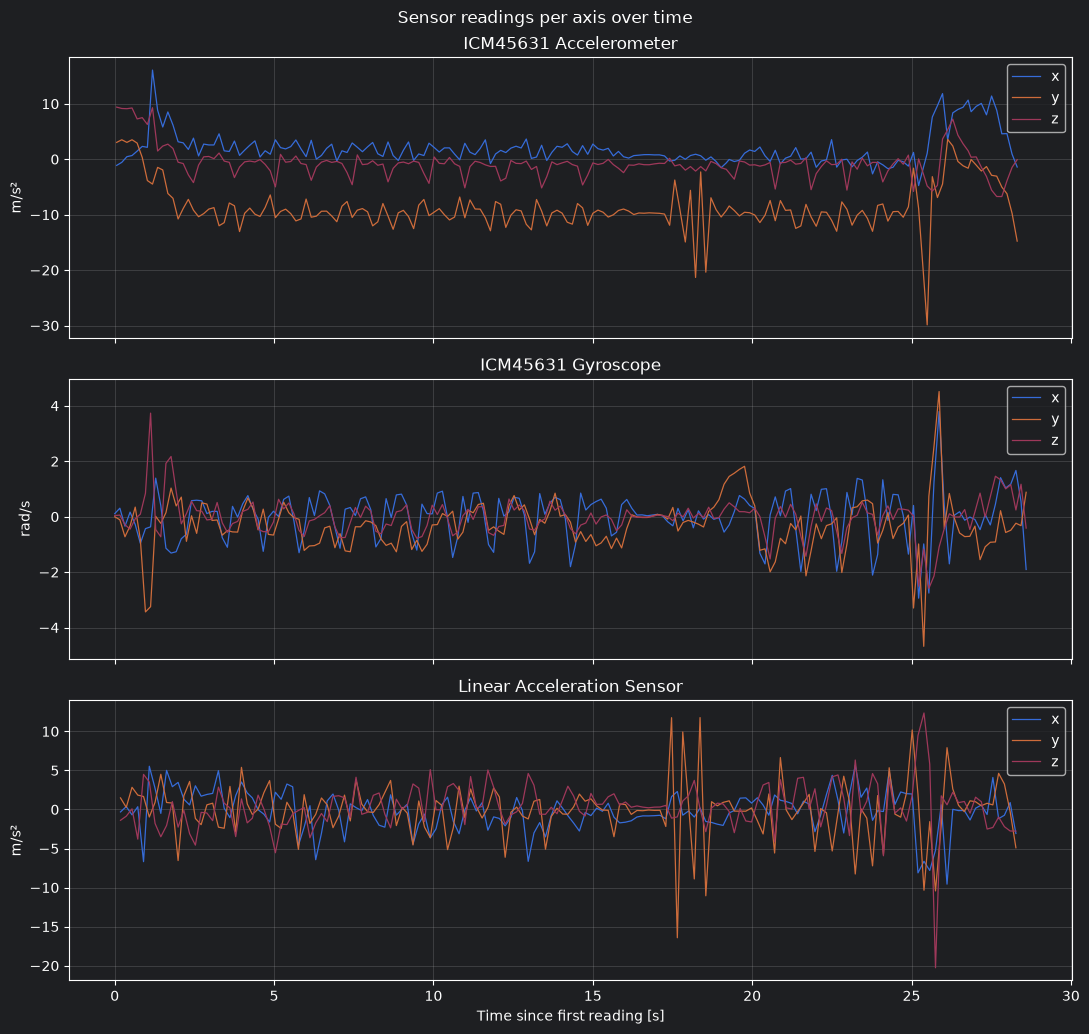

In [7]:
UNITS = {1: 'm/s²', 4: 'rad/s', 10: 'm/s²'}

sensors = sorted(df['sensorId'].unique())

fig, axes = plt.subplots(len(sensors), 1, figsize=(11, 3.5 * len(sensors)),
                         sharex=True, squeeze=False)

for ax, sensor in zip(axes.flat, sensors):
    sub = df[df['sensorId'] == sensor]
    for axis in ['x', 'y', 'z']:
        ax.plot(sub['t_rel'], sub[axis], linewidth=0.9, label=axis)
    ax.set_title(sensor)
    ax.set_ylabel(UNITS[sub['sensorType'].iloc[0]])
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

axes.flat[-1].set_xlabel('Time since first reading [s]')
fig.suptitle('Sensor readings per axis over time')
fig.tight_layout()
plt.show()

### 6.2 Magnitude over time

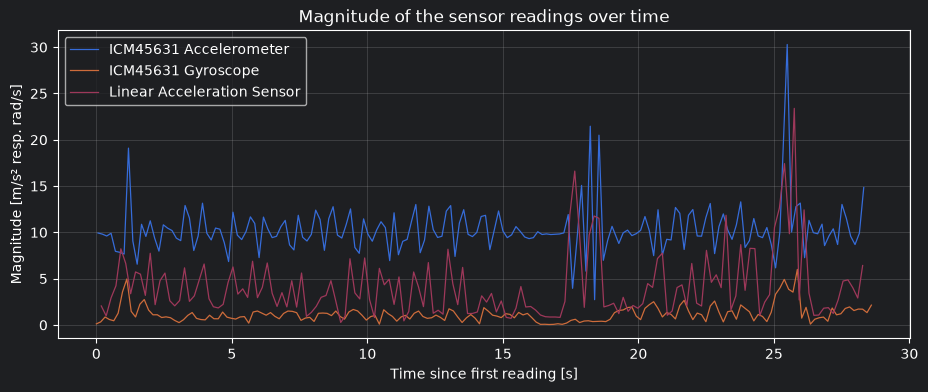

In [8]:
fig, ax = plt.subplots(figsize=(11, 4))

for sensor in sensors:
    sub = df[df['sensorId'] == sensor]
    ax.plot(sub['t_rel'], sub['magnitude'], linewidth=0.9, label=sensor)

ax.set_title('Magnitude of the sensor readings over time')
ax.set_xlabel('Time since first reading [s]')
ax.set_ylabel('Magnitude [m/s² resp. rad/s]')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

### 6.3 Distribution of the values per axis and sensor

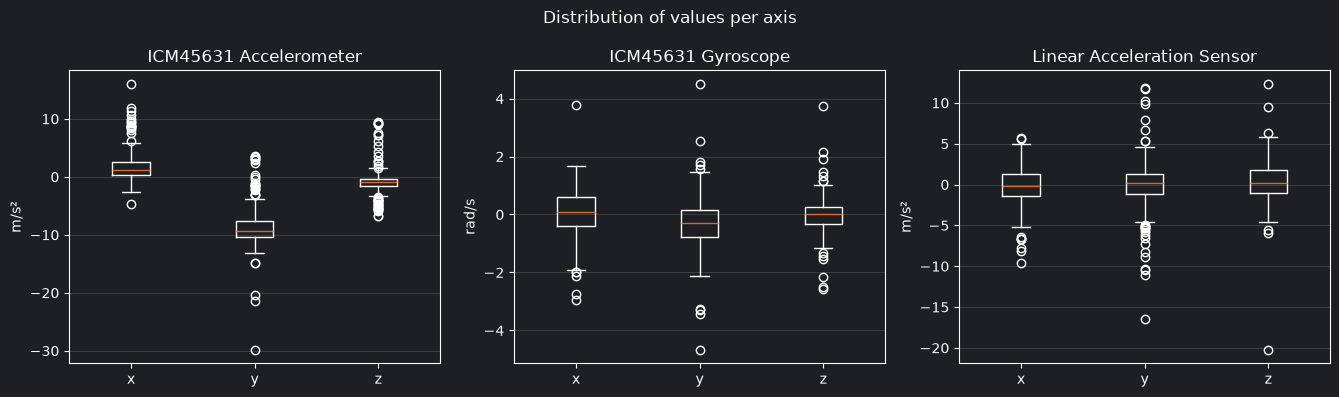

In [9]:
fig, axes = plt.subplots(1, len(sensors), figsize=(4.5 * len(sensors), 4), squeeze=False)

for ax, sensor in zip(axes.flat, sensors):
    sub = df[df['sensorId'] == sensor]
    ax.boxplot([sub['x'], sub['y'], sub['z']], tick_labels=['x', 'y', 'z'])
    ax.set_title(sensor)
    ax.set_ylabel(UNITS[sub['sensorType'].iloc[0]])
    ax.grid(True, axis='y', alpha=0.3)

fig.suptitle('Distribution of values per axis')
fig.tight_layout()
plt.show()

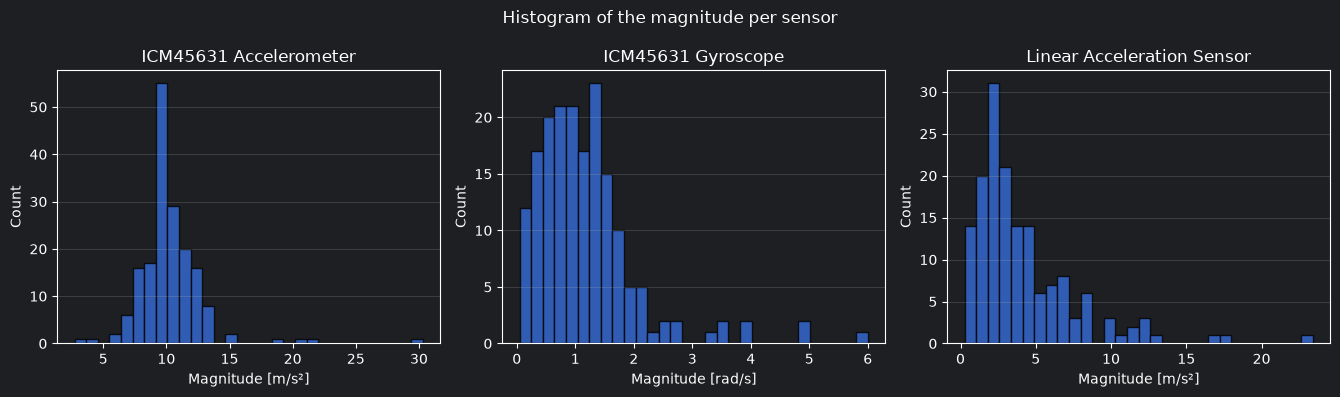

In [10]:
fig, axes = plt.subplots(1, len(sensors), figsize=(4.5 * len(sensors), 4), squeeze=False)

for ax, sensor in zip(axes.flat, sensors):
    sub = df[df['sensorId'] == sensor]
    ax.hist(sub['magnitude'], bins=30, edgecolor='black', alpha=0.8)
    ax.set_title(sensor)
    ax.set_xlabel(f"Magnitude [{UNITS[sub['sensorType'].iloc[0]]}]")
    ax.set_ylabel('Count')
    ax.grid(True, axis='y', alpha=0.3)

fig.suptitle('Histogram of the magnitude per sensor')
fig.tight_layout()
plt.show()

### 6.4 Smoothed activity profile

A rolling mean of the linear acceleration magnitude shows *when* during the recording
the device was moved strongly, with the high-frequency noise removed.

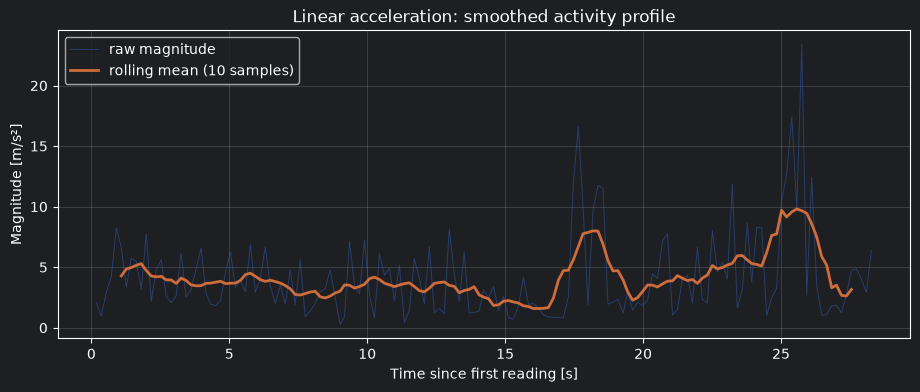

In [11]:
lin = df[df['sensorType'] == 10].sort_values('t_rel')

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(lin['t_rel'], lin['magnitude'], linewidth=0.7, alpha=0.4, label='raw magnitude')
ax.plot(lin['t_rel'], lin['magnitude'].rolling(window=10, center=True).mean(),
        linewidth=2, label='rolling mean (10 samples)')
ax.set_title('Linear acceleration: smoothed activity profile')
ax.set_xlabel('Time since first reading [s]')
ax.set_ylabel('Magnitude [m/s²]')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()